In [8]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## Test validation method

In [39]:
def check_test_conditions(res_df: pd.DataFrame, pset: float):

    df_copy = res_df.copy()
    df_copy["R_ohms"] = float(file.split("\\")[-1].split("_")[-2][1:])  # Creating a column for the resistance. The value is part of the file name
    df_copy["H_mH"] = float(file.split("\\")[-1].split("_")[-3][1:])
    u_col = df_copy["Vac:1"]   # phase a voltage
    u_rms_col = df_copy["Vrms"]
    p_col = df_copy["Pac"]

    # Compute steady-state average power after 48000 samples
    Pss = round(p_col.iloc[48000:].mean(), 3)
    delta_Pss = abs(Pss - pset)/1200

    # Check for distortion in ac voltage
    u_rms1 = u_rms_col.iloc[28000:30000].mean()
    u_rms2 = u_rms_col.iloc[30000:32000].mean()
    u_rms_error = round((u_rms1 - u_rms2)/400 ,3)  # Divide by 400 to convert to per unit
    
    return abs(u_rms_error), round(delta_Pss, 3), df_copy


### Step up power reference response

In [47]:
l_files = glob.glob("..\\output\\simulation_results\\step_up_power_ref_response\\*.csv")
df1 = pd.read_csv(l_files[1], index_col=0)
df1.tail()

,Vac:1,Vac:2,Vac:3,Vrms,Idc,Pac,Vdc_ref,Vdc
TIME,,,,,,,,
4.9996,-4.905859,-281.785233,286.691092,402.380210,1.589887,1000.007876,640.0,630.743537
4.9997,5.467231,-287.197617,281.730386,402.378439,1.589817,1000.003194,640.0,630.737399
4.9998,15.719850,-292.156594,276.436744,402.378252,1.589749,1000.003754,640.0,630.728303
4.9999,26.021832,-296.673623,270.651790,402.375875,1.589683,1000.004343,640.0,630.718618
5.0000,36.222040,-300.974059,264.752019,402.376428,1.589620,1000.003813,640.0,630.706918


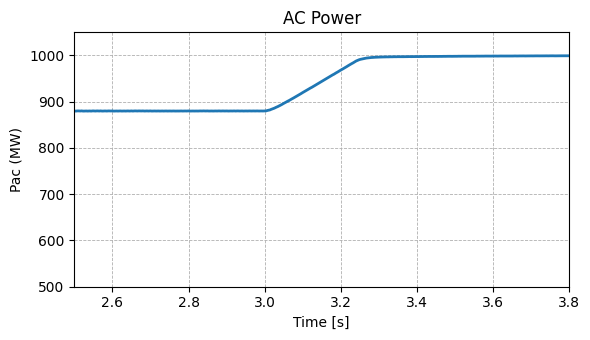

In [69]:
fig, ax = plt.subplots(figsize=(6, 3.5))

df1["Pac"].iloc[25000:38000].plot(ax=ax, linewidth=2)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Pac (MW)")

ax.set_xlim(2.5, 3.8)
ax.set_ylim(500, 1050)

ax.grid(True, which="both", linestyle="--", linewidth=0.6)
plt.title("AC Power")
plt.tight_layout()
plt.show()

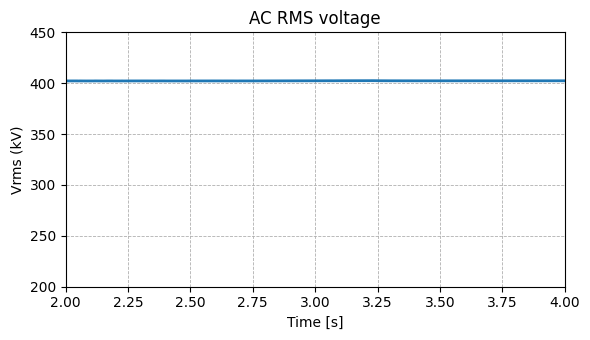

In [62]:
fig, ax = plt.subplots(figsize=(6, 3.5))

df1["Vrms"].iloc[20000:40000].plot(ax=ax, linewidth=2)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Vrms (kV)")

ax.set_xlim(2, 4)
ax.set_ylim(200, 450)

ax.grid(True, which="both", linestyle="--", linewidth=0.6)
plt.title("AC RMS voltage")
plt.tight_layout()
plt.show()

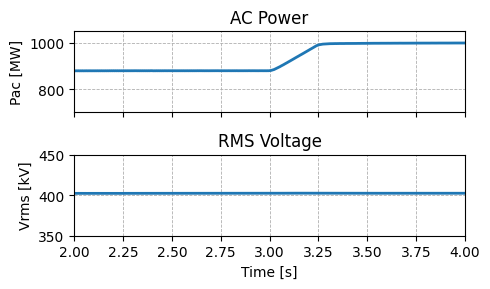

In [87]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 3), sharex=True)

df1["Pac"].iloc[20000:40000].plot(ax=ax1, linewidth=2)
ax1.set_ylabel("Pac [MW]")
ax1.set_title("AC Power")
ax1.set_xlim(2, 4)
ax1.set_ylim(700, 1050)
ax1.grid(True, which="both", linestyle="--", linewidth=0.6)

df1["Vrms"].iloc[20000:40000].plot(ax=ax2, linewidth=2)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Vrms [kV]")
ax2.set_title("RMS Voltage")
ax2.set_xlim(2, 4)
ax2.set_ylim(350, 450)
ax2.grid(True, which="both", linestyle="--", linewidth=0.6)

plt.tight_layout()

output_file = Path("summary/step_up_p_ref.pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_file)

In [40]:
csv_files = glob.glob("..\\output\\simulation_results\\step_up_power_ref_response\\*.csv")
pset = 1000.   # final value of power
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        u_rms_error, delta_Pss, result_df = check_test_conditions(file_df, pset)
    except IndexError:
        print(file)
        continue
    if delta_Pss > 0.002:
        test_var = 0
    elif u_rms_error > 0.001:  #  If error is greater than 0.001 p.u
        test_var = 0
    result_df["u_rms_error"] = u_rms_error
    result_df["delta_Pss"] = delta_Pss
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
result_summary_df = pd.concat(result_summary, axis=0).reset_index(drop=True)

output_file = Path("summary\\step_up_p_ref_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df.to_csv(output_file, index=True)

In [41]:
result_summary_df.head()

,Vac:1,Vac:2,Vac:3,Vrms,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,u_rms_error,delta_Pss,score
0,36.272854,-300.989891,264.717038,402.378154,1.606439,1000.007709,640.0,624.169542,10.0,400.0,0.0,0.0,1.0
1,36.222040,-300.974059,264.752019,402.376428,1.589620,1000.003813,640.0,630.706918,6.0,400.0,0.0,0.0,1.0
2,36.253297,-300.905077,264.651780,402.379038,1.594044,1000.002570,640.0,629.068528,7.0,400.0,0.0,0.0,1.0
3,36.279791,-300.623743,264.343952,402.374808,1.598144,1000.002020,640.0,627.409517,8.0,400.0,0.0,0.0,1.0
4,36.266373,-300.725997,264.459624,402.377860,1.602104,1000.007712,640.0,625.774628,9.0,400.0,0.0,0.0,1.0


In [42]:
result_summary_df[result_summary_df['score']==1].shape

(45, 13)

In [43]:
result_summary_df.shape

(45, 13)

### Step down power reference response

In [70]:
l_files = glob.glob("..\\output\\simulation_results\\step_down_power_ref_response\\*.csv")
df2 = pd.read_csv(l_files[1], index_col=0)
df2.tail()

,Vac:1,Vac:2,Vac:3,Vrms,Idc,Pac,Vdc_ref,Vdc
TIME,,,,,,,,
4.9996,-11.542969,-278.435535,289.978504,402.054710,1.202926,760.046299,640.0,633.034984
4.9997,-1.096455,-284.023807,285.120262,402.055350,1.202863,760.047378,640.0,633.035772
4.9998,9.142065,-288.857933,279.715867,402.055791,1.202800,760.052590,640.0,633.034652
4.9999,19.467163,-293.456570,273.989407,402.055881,1.202737,760.052073,640.0,633.029306
5.0000,29.657852,-297.633552,267.975700,402.053993,1.202677,760.049399,640.0,633.022740


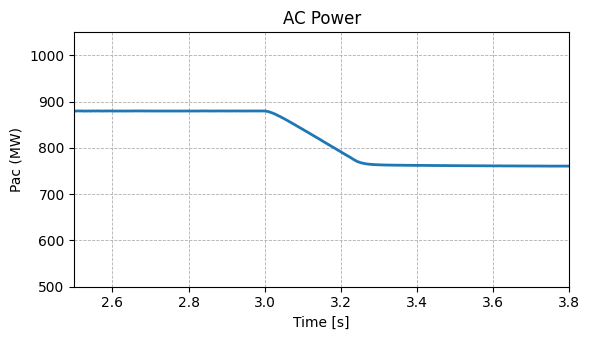

In [71]:
fig, ax = plt.subplots(figsize=(6, 3.5))

df2["Pac"].iloc[25000:38000].plot(ax=ax, linewidth=2)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Pac (MW)")

ax.set_xlim(2.5, 3.8)
ax.set_ylim(500, 1050)

ax.grid(True, which="both", linestyle="--", linewidth=0.6)
plt.title("AC Power")
plt.tight_layout()
plt.show()

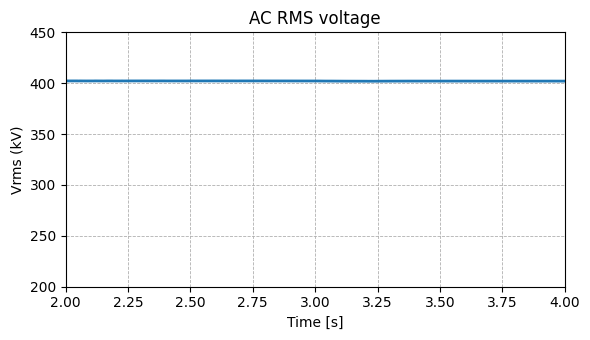

In [72]:
fig, ax = plt.subplots(figsize=(6, 3.5))

df2["Vrms"].iloc[20000:40000].plot(ax=ax, linewidth=2)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Vrms (kV)")

ax.set_xlim(2, 4)
ax.set_ylim(200, 450)

ax.grid(True, which="both", linestyle="--", linewidth=0.6)
plt.title("AC RMS voltage")
plt.tight_layout()
plt.show()

In [45]:
csv_files = glob.glob("..\\output\\simulation_results\\step_down_power_ref_response\\*.csv")
pset = 760.    # final value of power
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        u_rms_error, delta_Pss, result_df = check_test_conditions(file_df, pset)
    except IndexError:
        print(file)
        continue
    if delta_Pss > 0.002:
        test_var = 0
    elif u_rms_error > 0.001:  #  If error is greater than 0.001 p.u
        test_var = 0
    result_df["u_rms_error"] = u_rms_error
    result_df["delta_Pss"] = delta_Pss
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
result_summary_df2 = pd.concat(result_summary, axis=0).reset_index(drop=True)

output_file = Path("summary\\step_down_p_ref_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df2.to_csv(output_file, index=True)

In [46]:
result_summary_df2.head()

,Vac:1,Vac:2,Vac:3,Vrms,Idc,Pac,Vdc_ref,Vdc,R_ohms,H_mH,u_rms_error,delta_Pss,score
0,29.710612,-298.299131,268.588519,402.067586,1.211759,760.044795,640.0,628.121705,10.0,400.0,0.0,0.0,1.0
1,29.657852,-297.633552,267.975700,402.053993,1.202677,760.049399,640.0,633.022740,6.0,400.0,0.0,0.0,1.0
2,29.740361,-297.880806,268.140444,402.061171,1.204510,760.051186,640.0,631.811316,7.0,400.0,0.0,0.0,1.0
3,29.816681,-297.925200,268.108519,402.056540,1.207020,760.050265,640.0,630.570824,8.0,400.0,0.0,0.0,1.0
4,29.771660,-298.139377,268.367717,402.061724,1.209462,760.049187,640.0,629.353660,9.0,400.0,0.0,0.0,1.0


In [73]:
result_summary_df2[result_summary_df2['score']==1].shape

(45, 13)

In [74]:
result_summary_df2.shape

(45, 13)